In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
outputMLPKAN = pd.read_csv('./feynmantest/kan_feynman_results_MLPKAN.csv')
outputMLPKANtorch = pd.read_csv('./feynmantest/kan_feynman_results_MLPKANtorch.csv')
outputefficientKAN = pd.read_csv('./feynmantest/kan_feynman_results_efficientKAN.csv')
outputMLP = pd.read_csv('./feynmantest/kan_feynman_results_standardMLP.csv')
outputFastMLPKAN = pd.read_csv('./feynmantest/kan_feynman_results_FastMLPKAN.csv')
outputFastKAN = pd.read_csv('./feynmantest/kan_feynman_results_FastKAN.csv')

In [3]:
high_r2MLPKAN = outputMLPKAN[outputMLPKAN['R2 Score'] > 0.99]
print(high_r2MLPKAN.shape[0])
print(outputMLPKAN['R2 Score'].mean())

high_r2MLPKANtorch = outputMLPKANtorch[outputMLPKANtorch['R2 Score'] > 0.99]
print(high_r2MLPKANtorch.shape[0])
print(outputMLPKANtorch['R2 Score'].mean())

high_r2efficientKAN = outputefficientKAN[outputefficientKAN['R2 Score'] > 0.99]
print(high_r2efficientKAN.shape[0])
print(outputefficientKAN['R2 Score'].mean())

high_r2MLP = outputMLP[outputMLP['R2 Score'] > 0.99]
print(high_r2MLP.shape[0])
print(outputMLP['R2 Score'].mean())

high_r2FastMLPKAN = outputFastMLPKAN[outputFastMLPKAN['R2 Score'] > 0.99]
print(high_r2FastMLPKAN.shape[0])
print(outputFastMLPKAN['R2 Score'].mean())

high_r2FastKAN = outputFastKAN[outputFastKAN['R2 Score'] > 0.99]
print(high_r2FastKAN.shape[0])
print(outputFastKAN['R2 Score'].mean())



13
0.9466959155839065
16
0.9516314514752092
25
0.983130668771678
26
0.9864709295075516
27
0.9794391393661499
0
0.794896125793457


In [4]:
print(high_r2MLPKAN['time'].mean())
print(high_r2MLPKANtorch['time'].mean())
print(high_r2efficientKAN['time'].mean())
print(high_r2MLP['time'].mean())
print(high_r2FastMLPKAN['time'].mean())


6.155864199990622
3.0809598124978947
2.640974140006583
0.8242800077065252
1.2101709666549814


C:\Users\Maarten\AppData\Local\Temp\ipykernel_21596\126919975.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([high_r2FastMLPKAN['time'], high_r2efficientKAN['time'], high_r2MLP['time']],


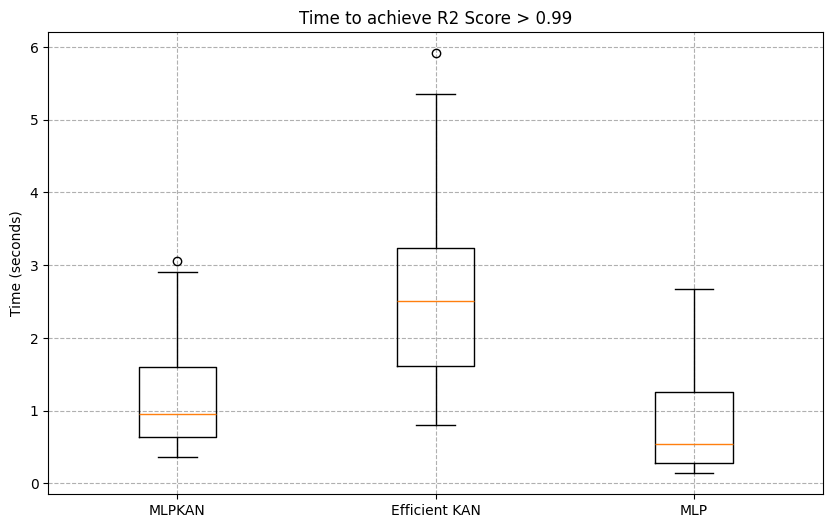

In [5]:
plt.figure(figsize=(10, 6))
plt.boxplot([high_r2FastMLPKAN['time'], high_r2efficientKAN['time'], high_r2MLP['time']], 
            labels=['MLPKAN', 'Efficient KAN', 'MLP'])
plt.ylabel('Time (seconds)')
plt.title('Time to achieve R2 Score > 0.99')
plt.grid(True, which="both", ls="--")
plt.show()

C:\Users\Maarten\AppData\Local\Temp\ipykernel_21596\4164404228.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(r2_scores, labels=model_names)


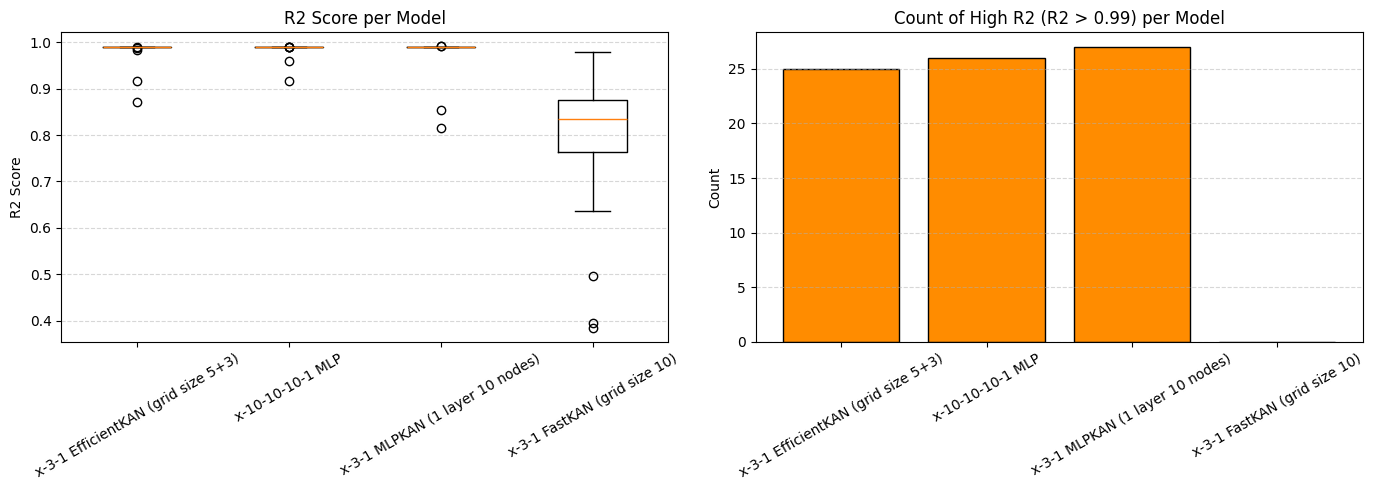

In [9]:
model_names = ['x-3-1 EfficientKAN (grid size 5+3)', 'x-10-10-10-1 MLP', 'x-3-1 MLPKAN (1 layer 10 nodes)', 'x-3-1 FastKAN (grid size 10)']

r2_scores = [
    outputefficientKAN['R2 Score'],
    outputMLP['R2 Score'],
    outputFastMLPKAN['R2 Score'],
    outputFastKAN['R2 Score'],
]

high_r2_counts = [
    high_r2efficientKAN.shape[0],
    high_r2MLP.shape[0],
    high_r2FastMLPKAN.shape[0],
    high_r2FastKAN.shape[0],
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(r2_scores, labels=model_names)
axes[0].set_title('R2 Score per Model')
axes[0].set_ylabel('R2 Score')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

axes[1].bar(model_names, high_r2_counts, color='darkorange', edgecolor='black')
axes[1].set_title('Count of High R2 (R2 > 0.99) per Model')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()